# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


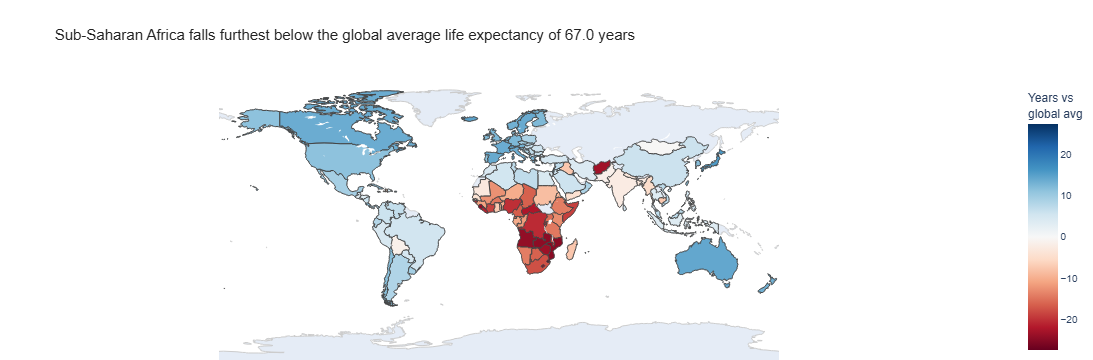

In [2]:
gm_2007 = px.data.gapminder()[px.data.gapminder()['year'] == 2007].copy()

global_mean = gm_2007['lifeExp'].mean()
gm_2007['deviation'] = gm_2007['lifeExp'] - global_mean

fig = px.choropleth(
    gm_2007,
    locations='iso_alpha',
    color='deviation',
    hover_name='country',
    hover_data={
        'lifeExp': ':.1f',
        'deviation': ':.1f',
        'iso_alpha': False
    },
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    labels={
        'deviation': 'Deviation from global avg (years)',
        'lifeExp': 'Life Expectancy'
    }
)

fig.update_layout(
    title=dict(
        text=f"Sub-Saharan Africa falls furthest below the global average life expectancy of {global_mean:.1f} years",
        font=dict(family='Arial', size=15, color='#222222')
    ),
    paper_bgcolor='white',
    font=dict(family='Arial'),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='#CCCCCC',
        bgcolor='white'
    ),
    coloraxis_colorbar=dict(
        title='Years vs<br>global avg',
        tickfont=dict(family='Arial', size=10)
    ),
    margin=dict(t=80, b=0, l=0, r=0)
)

fig.show()


## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:** *(https://github.com/isellsoap/deutschlandGeoJSON — German state boundaries)*

**Chart type chosen** (`px.choropleth`) **and reason:** px.choropleth` — shows regional boundaries at country level, no street-level detail needed.


**Colour scale chosen** (sequential or diverging) **and reason:**

Sequential (Blues) — population density is one-directional, 
higher values simply mean more people per km².


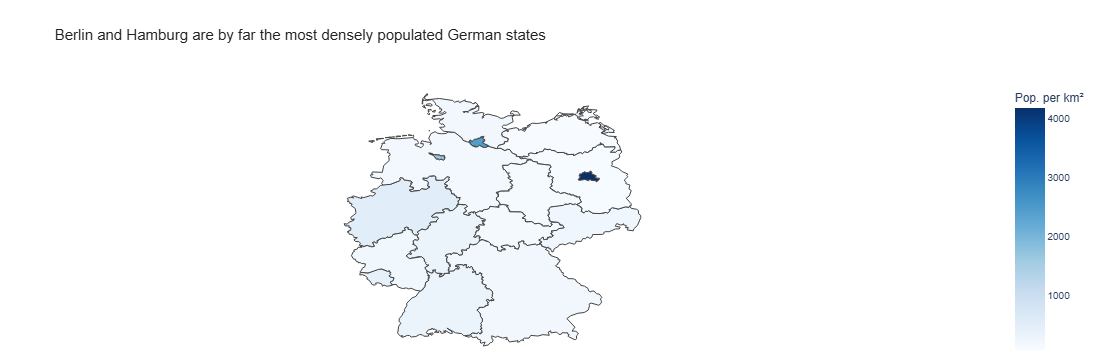

In [3]:
import urllib.request

# Load GeoJSON 
url = 'https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/4_niedrig.geo.json'
with urllib.request.urlopen(url) as response:
    germany_geojson = json.load(response)

# 2022
data = pd.DataFrame({
    'state': [
        'Bayern', 'Baden-Württemberg', 'Nordrhein-Westfalen', 'Hessen',
        'Niedersachsen', 'Sachsen', 'Berlin', 'Rheinland-Pfalz',
        'Brandenburg', 'Sachsen-Anhalt', 'Thüringen', 'Hamburg',
        'Schleswig-Holstein', 'Mecklenburg-Vorpommern', 'Saarland', 'Bremen'
    ],
    'pop_density': [
        187, 311, 526, 296, 167, 221, 4175, 206,
        85, 107, 135, 2438, 182, 69, 389, 1671
    ]
})

fig = px.choropleth(
    data,
    geojson=germany_geojson,
    locations='state',
    color='pop_density',
    featureidkey='properties.name',
    color_continuous_scale='Blues',
    labels={'pop_density': 'Population per km²'}
)

fig.update_geos(
    fitbounds='locations',
    visible=False
)

fig.update_layout(
    title=dict(
        text="Berlin and Hamburg are by far the most densely populated German states",
        font=dict(family='Arial', size=15, color='#222222')
    ),
    paper_bgcolor='white',
    font=dict(family='Arial'),
    coloraxis_colorbar=dict(
        title='Pop. per km²',
        tickfont=dict(family='Arial', size=10)
    ),
    margin=dict(t=80, b=0, l=0, r=0)
)

fig.show()